In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [100]:
# Load Dataset
df = pd.read_csv("../data/sales_data.csv")

# Create a folder to save charts
os.makedirs("visualizations", exist_ok=True)

In [101]:
# Data set Overview
print(df.head())

# shape
print("\nNumber of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

# column Names
print("\n", df.columns)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [102]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [103]:
# missing values
print(df.isnull().sum())

# Duplicate Rows
print("Duplicates Rows :", df.duplicated().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicates Rows : 0


In [104]:
# Data Types
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [105]:
# convert order date and ship date into datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


## Observation

- The dataset contains **9,994 rows** and **21 columns**, providing sufficient data for business analysis.
- Each row represents a unique sales transaction with details such as customer information, product details, sales, profit, quantity, discount, shipping, and location.
- The dataset consists of both **numerical** and **categorical** variables, making it suitable for statistical analysis and business insights.
- The summary statistics indicate that sales and profit values vary significantly across orders, and some transactions resulted in **negative profit**, indicating losses.
- The missing value check shows that the dataset contains **no missing values**, so no data imputation is required.
- Duplicate records were checked, and **no duplicate rows** were found, ensuring data quality.
- The **Order Date** and **Ship Date** columns were successfully converted to the **datetime** data type, enabling time-based analysis such as monthly and yearly sales trends.
- Overall, the dataset is clean, complete, and well-prepared for further exploratory data analysis and business insights.

In [106]:
# Business KPI Analysis

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
total_quantity = df["Quantity"].sum()

average_sales = df["Sales"].mean()
average_profit = df["Profit"].mean()
average_discount = df["Discount"].mean()

# Profit Margin
profit_margin = (total_profit / total_sales) * 100

# Display KPIs

print("========== BUSINESS KPIs ==========\n")

print("Total Sales          :", round(total_sales, 2))
print("Total Profit         :", round(total_profit, 2))
print("Total Orders         :", total_orders)
print("Total Customers      :", total_customers)
print("Total Quantity Sold  :", total_quantity)
print("Average Sales        :", round(average_sales, 2))
print("Average Profit       :", round(average_profit, 2))
print("Average Discount     :", round(average_discount, 2))
print("Profit Margin (%)    :", round(profit_margin, 2))

========== BUSINESS KPIs ==========

Total Sales          : 2297200.86
Total Profit         : 286397.02
Total Orders         : 5009
Total Customers      : 793
Total Quantity Sold  : 37873
Average Sales        : 229.86
Average Profit       : 28.66
Average Discount     : 0.16
Profit Margin (%)    : 12.47


## Observation

- The company generated a **total sales revenue of 2,297,200.86** and earned a **total profit of 286,397.02**, indicating overall profitable business performance.
- A total of **5,009 unique orders** were placed by **793 customers**, reflecting a broad and active customer base.
- The company sold **37,873 units** across all orders during the analysis period.
- The **average sales per order** were **229.86**, while the **average profit per order** was **28.66**.
- The **average discount offered** was **16%**, suggesting that discounts are commonly used as part of the company's sales strategy.
- The overall **profit margin of 12.47%** indicates that the company is profitable, earning approximately **₹12.47** in profit for every **₹100** in sales.

# Category analysis

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


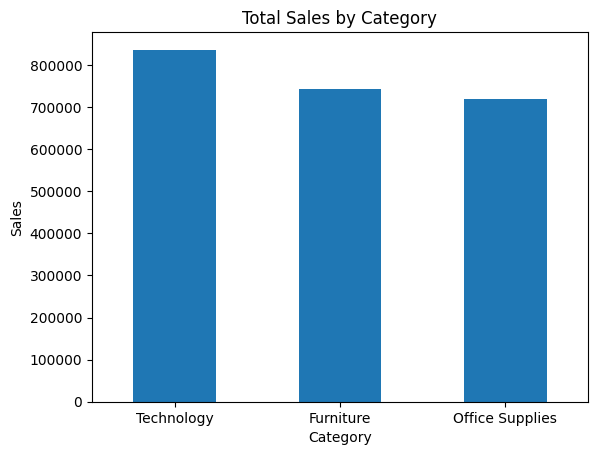

In [107]:
# Total Sales by category

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending = False)
print(category_sales)

# Bar chart
category_sales.plot(kind = "bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
  
plt.xticks(rotation = 0)

plt.savefig("visualizations/category_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


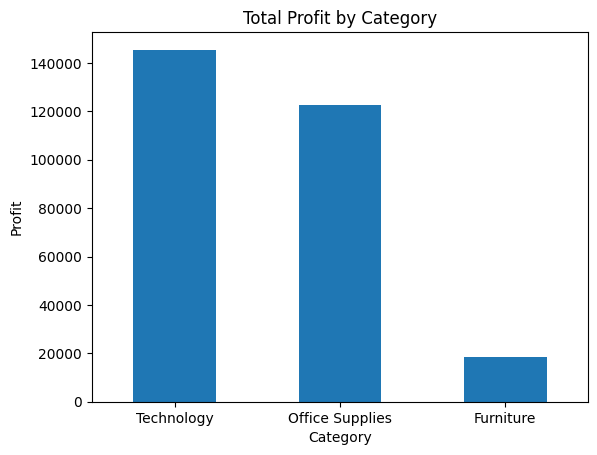

In [108]:
# Total Profit by Category

category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending = False)
print(category_profit)

# Bar Chart
category_profit.plot(kind = "bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.savefig("visualizations/category_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Category
Office Supplies    22906
Furniture           8028
Technology          6939
Name: Quantity, dtype: int64


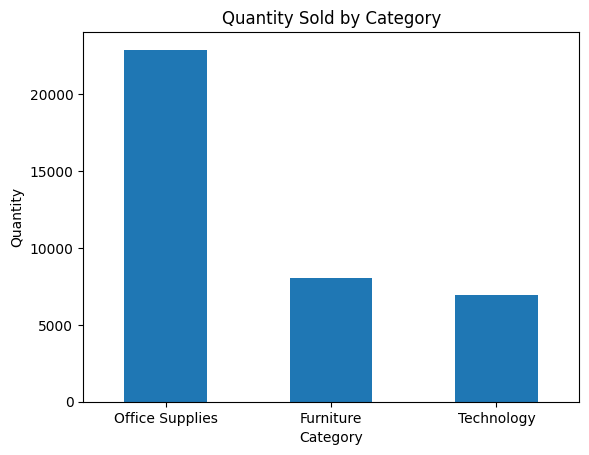

In [109]:
# Total Quantity Sold by Category

category_quantity = df.groupby("Category")["Quantity"].sum().sort_values(ascending=False)
print(category_quantity)

# Bar Chart
category_quantity.plot(kind="bar")

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity")

plt.xticks(rotation=0)
plt.savefig("visualizations/category_quantity.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

### Sales by Category
- **Technology** generated the highest sales with **836,154.03**, making it the top-performing category in terms of revenue.
- **Furniture** recorded the second-highest sales with **741,999.80**.
- **Office Supplies** generated **719,047.03** in sales, the lowest among the three categories.
- The sales difference between Furniture and Office Supplies is relatively small, while Technology leads by a noticeable margin.

### Profit by Category
- **Technology** earned the highest profit of **145,454.95**, indicating strong profitability.
- **Office Supplies** generated the second-highest profit of **122,490.80**.
- Although **Furniture** achieved high sales, it produced the lowest profit (**18,451.27**), suggesting lower profit margins compared to the other categories.

### Quantity Sold by Category
- **Office Supplies** recorded the highest quantity sold with **22,906 units**, indicating strong customer demand.
- **Furniture** sold **8,028 units**, ranking second.
- **Technology** sold **6,939 units**, the lowest quantity among all categories.
- Despite selling fewer units, Technology generated the highest sales and profit, indicating a higher average selling price per product.

# Sub-Category Analysis

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


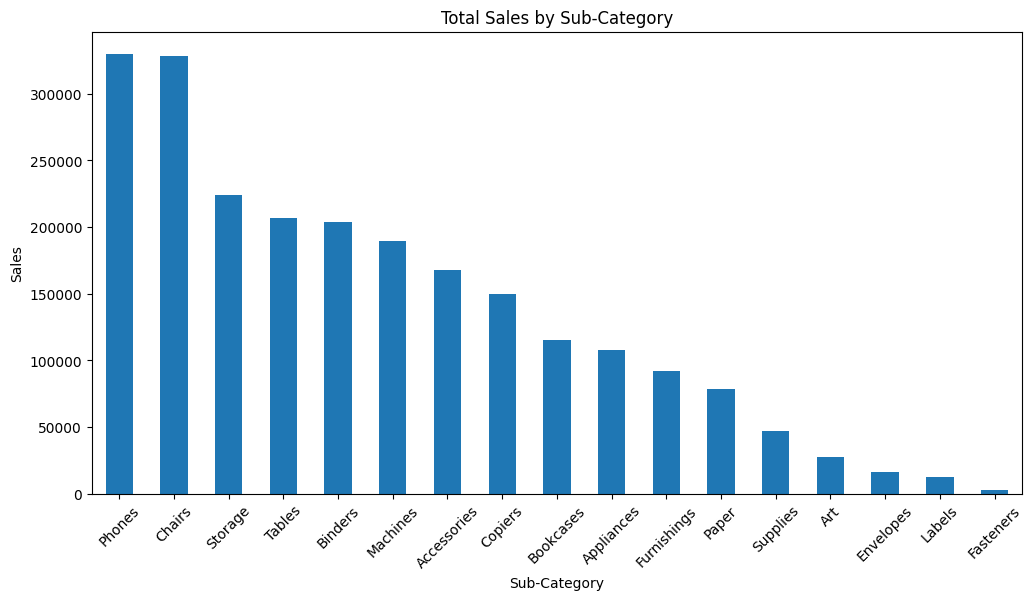

In [110]:
# Total Sales by Sub-Category

subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
print(subcategory_sales)

# Bar Chart

subcategory_sales.plot(kind="bar", figsize=(12,6))

plt.title("Total Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.savefig("visualizations/subcategory_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


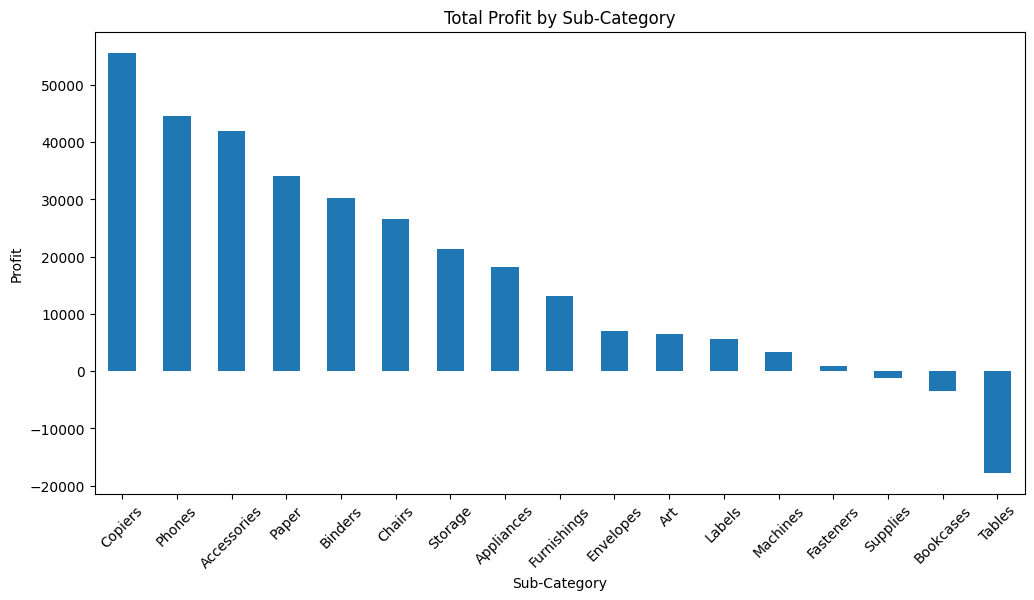

In [111]:
# Total Profit by Sub-Category

subcategory_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)
print(subcategory_profit)

# Bar Chart
subcategory_profit.plot(kind="bar", figsize=(12,6))

plt.title("Total Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.savefig("visualizations/subcategory_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Sub-Category
Binders        5974
Paper          5178
Furnishings    3563
Phones         3289
Storage        3158
Art            3000
Accessories    2976
Chairs         2356
Appliances     1729
Labels         1400
Tables         1241
Fasteners       914
Envelopes       906
Bookcases       868
Supplies        647
Machines        440
Copiers         234
Name: Quantity, dtype: int64


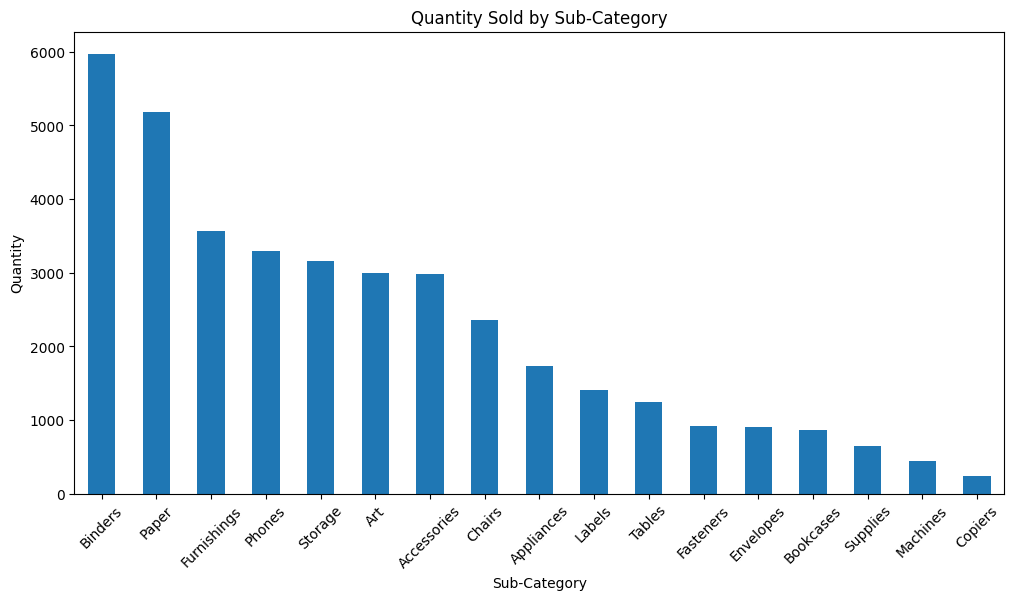

In [112]:
# Total Quantity Sold by Sub-Category

subcategory_quantity = df.groupby("Sub-Category")["Quantity"].sum().sort_values(ascending=False)
print(subcategory_quantity)

# Bar Chart

subcategory_quantity.plot(kind="bar", figsize=(12,6))

plt.title("Quantity Sold by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Quantity")

plt.xticks(rotation=45)

plt.savefig("visualizations/subcategory_quantity.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

### Sales by Sub-Category
- **Phones** generated the highest sales (**330,007.05**), followed closely by **Chairs** (**328,449.10**).
- **Storage**, **Tables**, and **Binders** also contributed significantly to total sales.
- **Fasteners** recorded the lowest sales (**3,024.28**), indicating low customer demand compared to other sub-categories.

### Profit by Sub-Category
- **Copiers** generated the highest profit (**55,617.82**), despite not having the highest sales.
- **Phones** and **Accessories** were also among the most profitable sub-categories.
- **Tables** recorded the highest loss (**-17,725.48**), while **Bookcases** and **Supplies** also generated negative profits.
- The presence of negative profits suggests that some sub-categories may have high costs or excessive discounting.

### Quantity Sold by Sub-Category
- **Binders** recorded the highest quantity sold (**5,974 units**), followed by **Paper** (**5,178 units**) and **Furnishings** (**3,563 units**).
- **Copiers** sold the fewest units (**234 units**), yet generated the highest profit, indicating a high profit per unit.
- High sales quantity does not necessarily result in high profit, as profitability varies across different sub-categories.

# Product Analysis

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


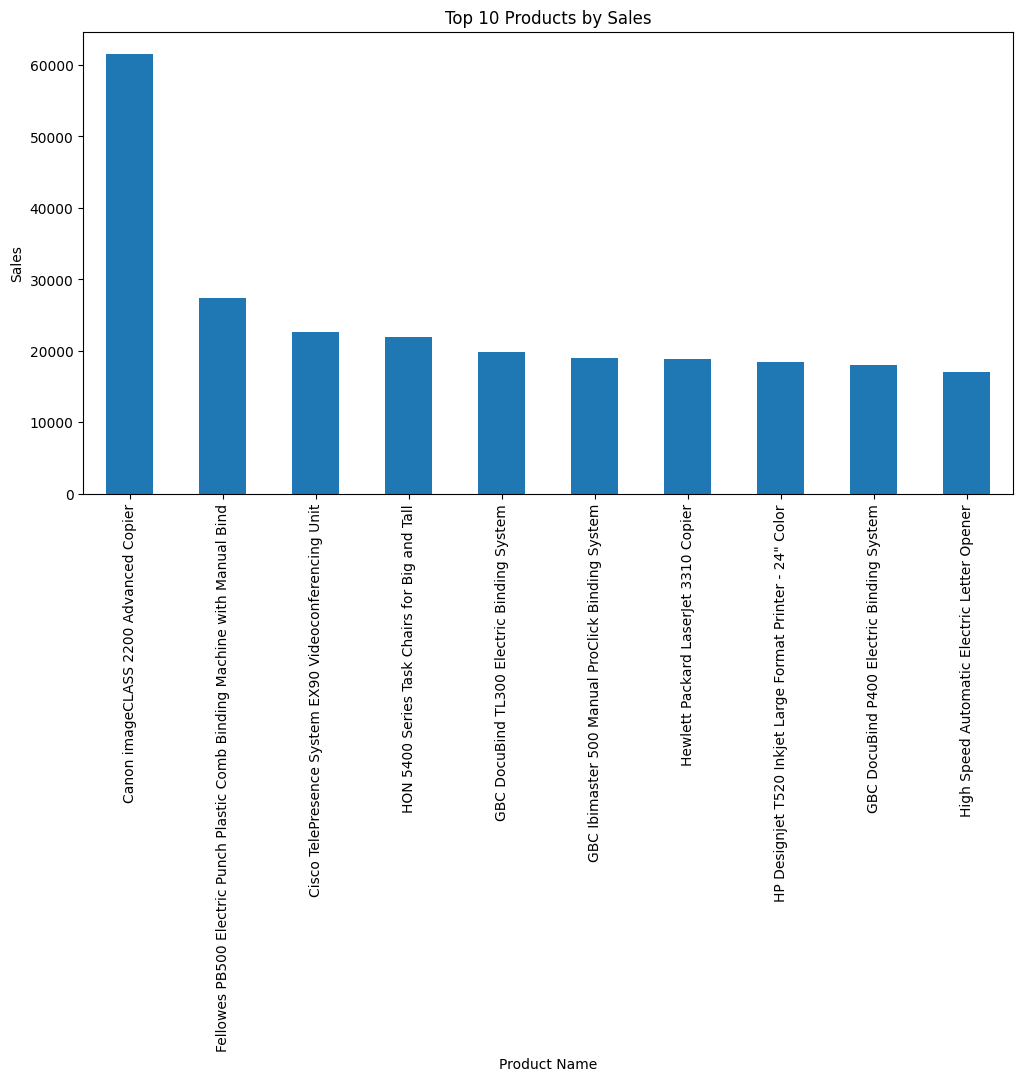

In [113]:
# Top 10 Products by Sales

product_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(product_sales)

# Bar Chart

product_sales.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")

plt.savefig("visualizations/product_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


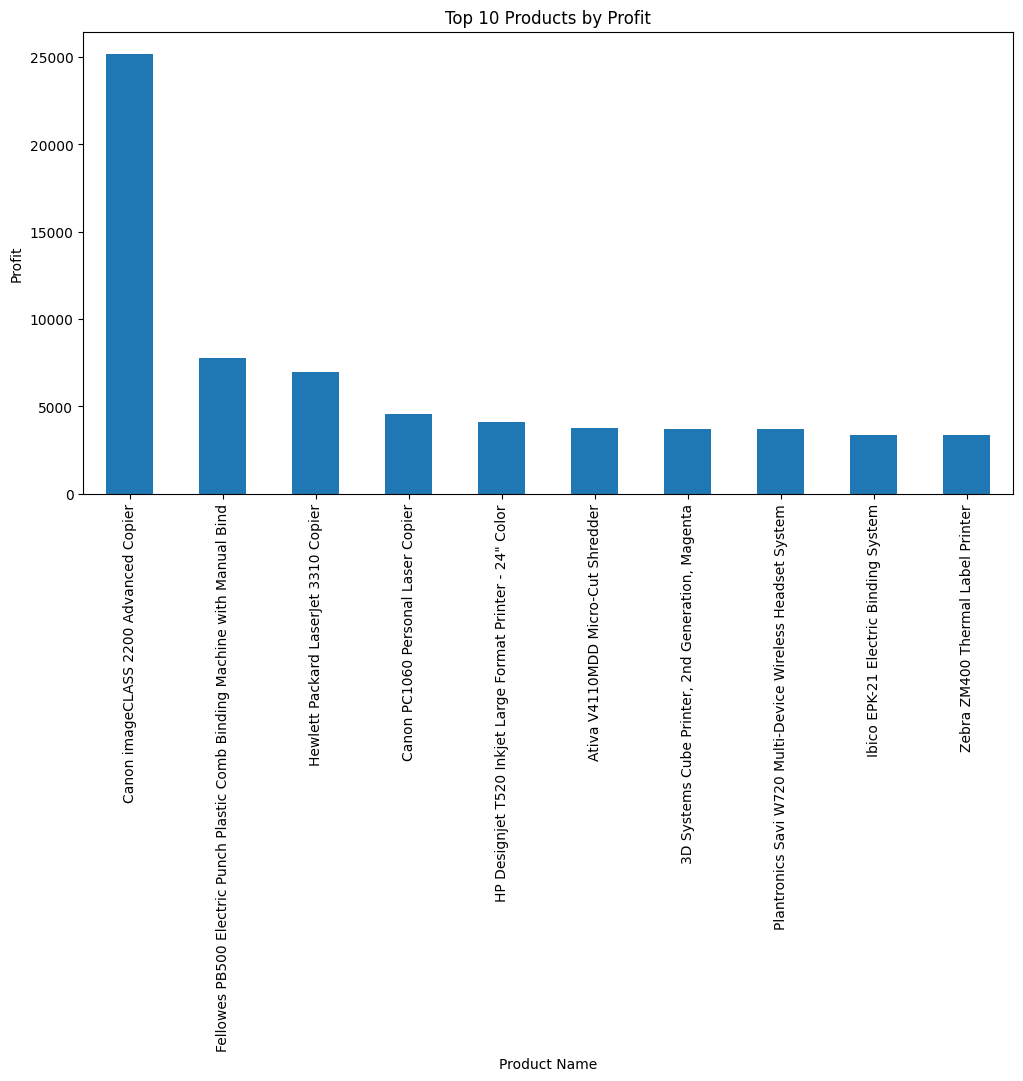

In [114]:
# Top 10 Products by Profit

product_profit = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)
print(product_profit)

# Bar Chart
product_profit.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Products by Profit")
plt.xlabel("Product Name")
plt.ylabel("Profit")

plt.savefig("visualizations/product_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Product Name
Staples                                                       215
Staple envelope                                               170
Easy-staple paper                                             150
Staples in misc. colors                                        86
KI Adjustable-Height Table                                     74
Storex Dura Pro Binders                                        71
Avery Non-Stick Binders                                        71
GBC Premium Transparent Covers with Diagonal Lined Pattern     67
Situations Contoured Folding Chairs, 4/Set                     64
Staple-based wall hangings                                     62
Name: Quantity, dtype: int64


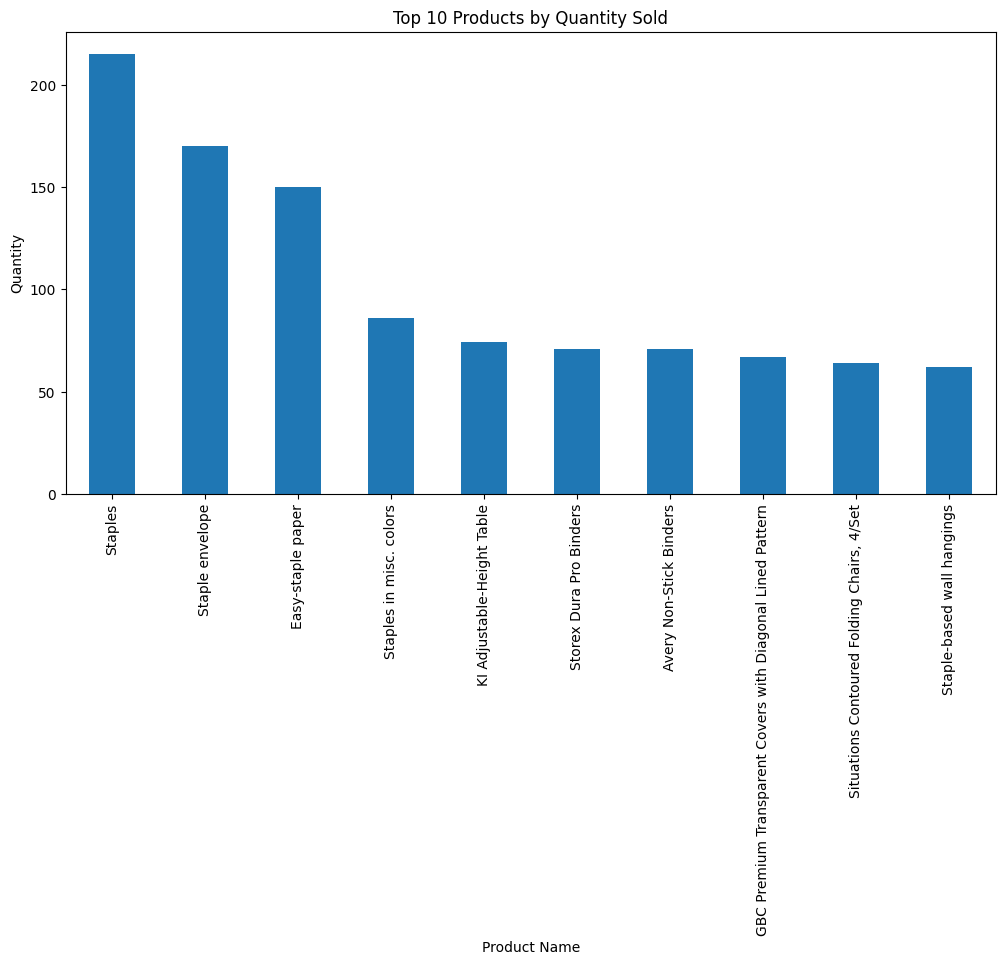

In [115]:
# Top 10 Products by Quantity Sold

product_quantity = df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False).head(10)
print(product_quantity)

# Bar Chart
product_quantity.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product Name")
plt.ylabel("Quantity")

plt.savefig("visualizations/product_quantity.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

### Top 10 Products by Sales
- The **Canon imageCLASS 2200 Advanced Copier** generated the highest sales (**61,599.82**), making it the top-selling product by revenue.
- Products such as the **Fellowes PB500 Electric Punch Plastic Comb Binding Machine** and **Cisco TelePresence System EX90 Videoconferencing Unit** also generated high sales.
- Most of the top-selling products are high-value office equipment and technology products, contributing significantly to total revenue.

### Top 10 Products by Profit
- The **Canon imageCLASS 2200 Advanced Copier** generated the highest profit (**25,199.93**), making it the most profitable product.
- Products like the **Fellowes PB500 Electric Punch Plastic Comb Binding Machine** and **Hewlett Packard LaserJet 3310 Copier** also generated substantial profits.
- Several technology and office equipment products appear among the top profitable products, indicating strong profitability in these product categories.

### Top 10 Products by Quantity Sold
- **Staples** recorded the highest quantity sold (**215 units**), followed by **Staple envelope** (**170 units**) and **Easy-staple paper** (**150 units**).
- Office stationery products dominate the list of highest-selling products by quantity, indicating frequent customer purchases.
- Products with the highest sales revenue are different from those with the highest quantity sold, showing that high-priced products generate more revenue even with fewer units sold.

# Regional Analysis

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


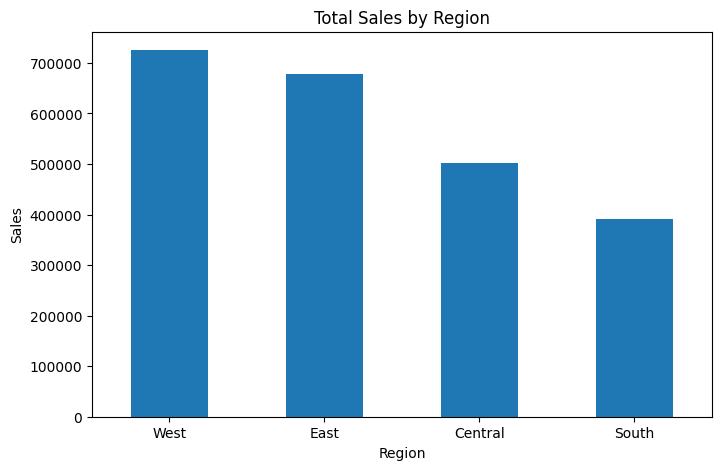

In [116]:
# Total Sales by Region

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(region_sales)

# Bar Chart
region_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.savefig("visualizations/region_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


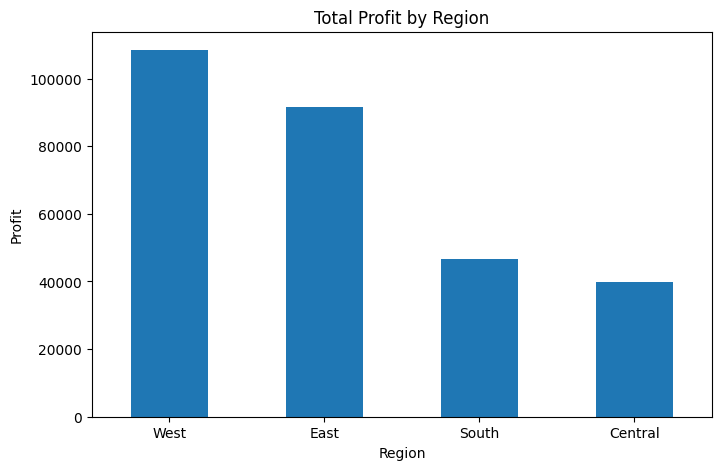

In [117]:
# Total Profit by Region

region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
print(region_profit)

# Bar Chart
region_profit.plot(kind="bar", figsize=(8,5))

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.savefig("visualizations/region_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Region
West       12266
East       10618
Central     8780
South       6209
Name: Quantity, dtype: int64


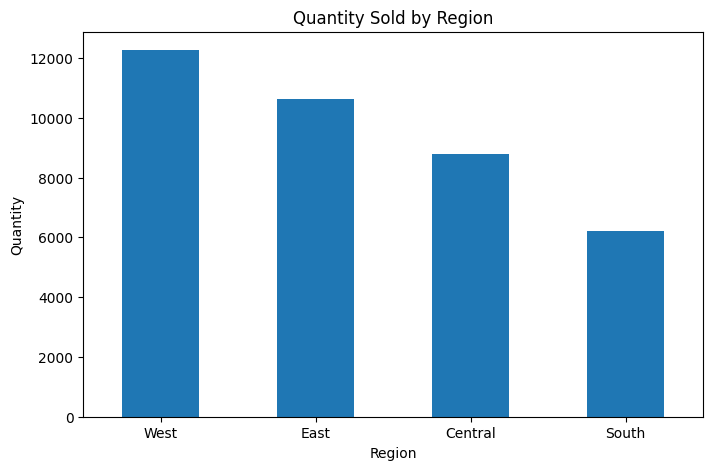

In [118]:
# Total Quantity Sold by Region

region_quantity = df.groupby("Region")["Quantity"].sum().sort_values(ascending=False)
print(region_quantity)

# Bar Chart
region_quantity.plot(kind="bar", figsize=(8,5))

plt.title("Quantity Sold by Region")
plt.xlabel("Region")
plt.ylabel("Quantity")

plt.xticks(rotation=0)

plt.savefig("visualizations/region_quantity.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

### Sales by Region
- The **West** region generated the highest sales (**725,457.82**), making it the leading contributor to overall revenue.
- The **East** region recorded the second-highest sales (**678,781.24**), followed by the **Central** and **South** regions.
- The **South** region generated the lowest sales (**391,721.91**) among all regions.

### Profit by Region
- The **West** region earned the highest profit (**108,418.45**), indicating strong business performance.
- The **East** region generated the second-highest profit (**91,522.78**).
- Although the **Central** region generated higher sales than the South region, it earned a lower profit.
- The **Central** region recorded the lowest profit (**39,706.36**) among all regions.

### Quantity Sold by Region
- The **West** region sold the highest number of products (**12,266 units**).
- The **East** region ranked second with **10,618 units**, followed by the **Central** and **South** regions.
- The **South** region recorded the lowest quantity sold (**6,209 units**), which is consistent with its lower sales performance.

# State Analysis

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64


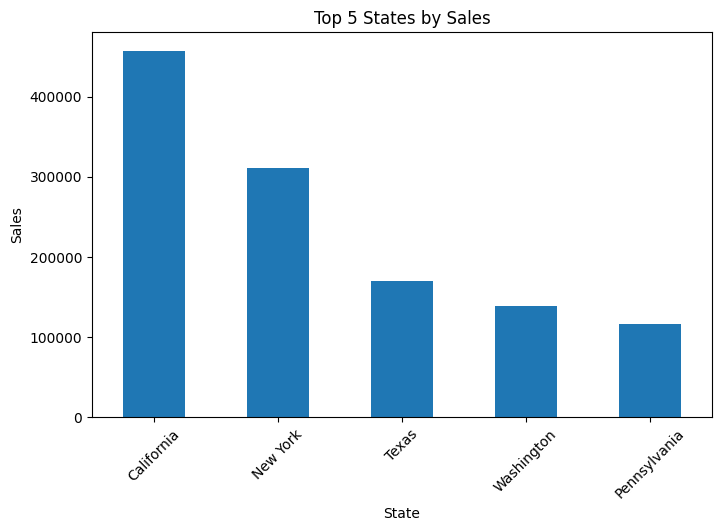

In [119]:
# Top 5 States by Sales

state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(5)
print(state_sales)

# Bar Chart
state_sales.plot(kind="bar", figsize=(8,5))

plt.title("Top 5 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.savefig("visualizations/state_sales.png", dpi=300, bbox_inches="tight")
plt.show()

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Name: Profit, dtype: float64


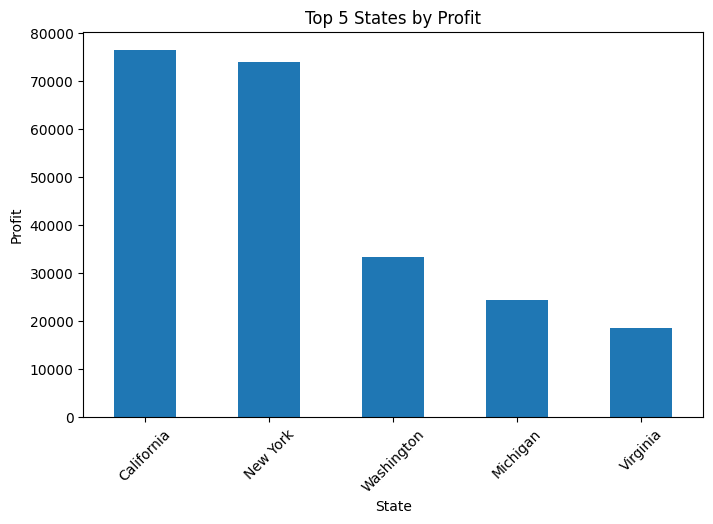

In [120]:
# Top 5 States by Profit

state_profit = df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(5)
print(state_profit)

# Bar Chart
state_profit.plot(kind="bar", figsize=(8,5))

plt.title("Top 5 States by Profit")
plt.xlabel("State")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.savefig("visualizations/state_profit.png", dpi=300, bbox_inches="tight")
plt.show()

State
California      7667
New York        4224
Texas           3724
Pennsylvania    2153
Washington      1883
Name: Quantity, dtype: int64


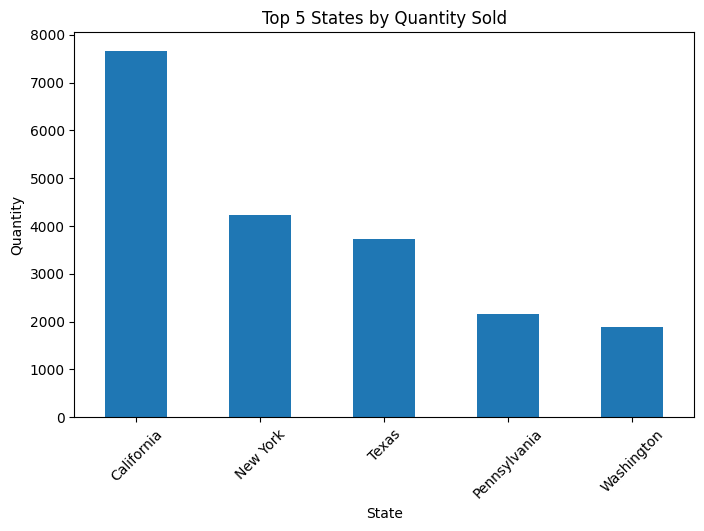

In [121]:
# Top 5 States by Quantity Sold

state_quantity = df.groupby("State")["Quantity"].sum().sort_values(ascending=False).head(5)
print(state_quantity)

# Bar Chart
state_quantity.plot(kind="bar", figsize=(8,5))

plt.title("Top 5 States by Quantity Sold")
plt.xlabel("State")
plt.ylabel("Quantity")

plt.xticks(rotation=45)

plt.savefig("visualizations/state_quantity.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

### Top 5 States by Sales
- **California** generated the highest sales (**457,687.63**), making it the leading contributor to the company's revenue.
- **New York** ranked second with **310,876.27** in sales, followed by **Texas**, **Washington**, and **Pennsylvania**.
- California and New York together contributed a significant portion of the company's total sales.

### Top 5 States by Profit
- **California** earned the highest profit (**76,381.39**), followed closely by **New York** (**74,038.55**).
- **Washington**, **Michigan**, and **Virginia** also generated strong profits.
- Although **Texas** ranked among the top states in sales, it did not appear in the top five for profit, indicating comparatively lower profitability.

### Top 5 States by Quantity Sold
- **California** sold the highest number of products (**7,667 units**), followed by **New York** (**4,224 units**) and **Texas** (**3,724 units**).
- **Pennsylvania** and **Washington** also recorded high product sales by quantity.
- California consistently ranked first in sales, profit, and quantity sold, making it the company's strongest-performing state.

# Customer Analysis

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


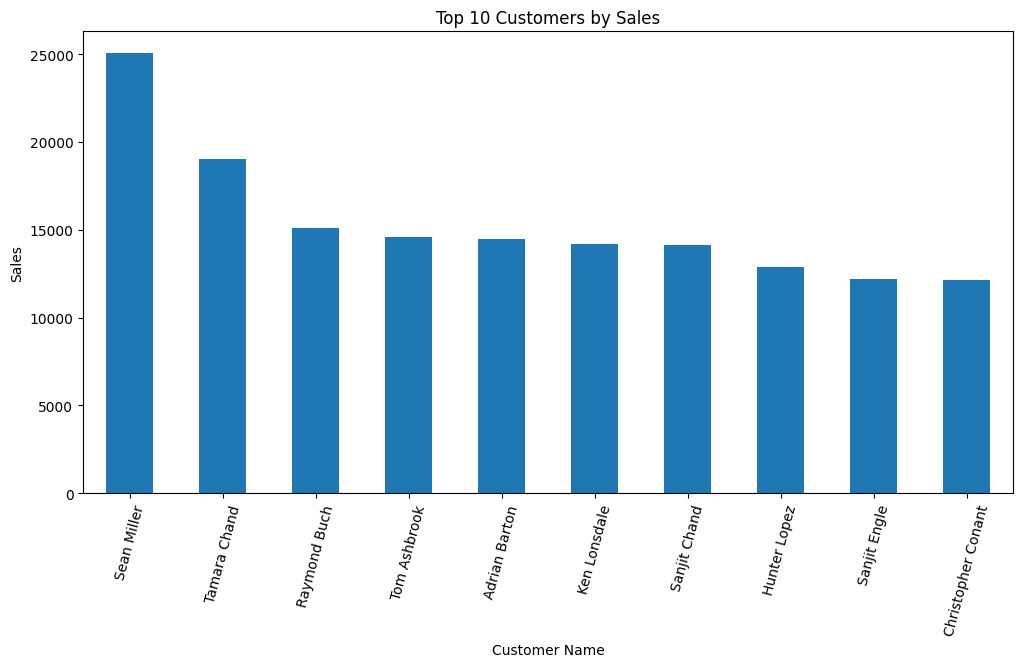

In [122]:
# Top 10 Customers by Sales

customer_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(customer_sales)

# Bar Chart
customer_sales.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Sales")

plt.xticks(rotation=75)

plt.savefig("visualizations/customer_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


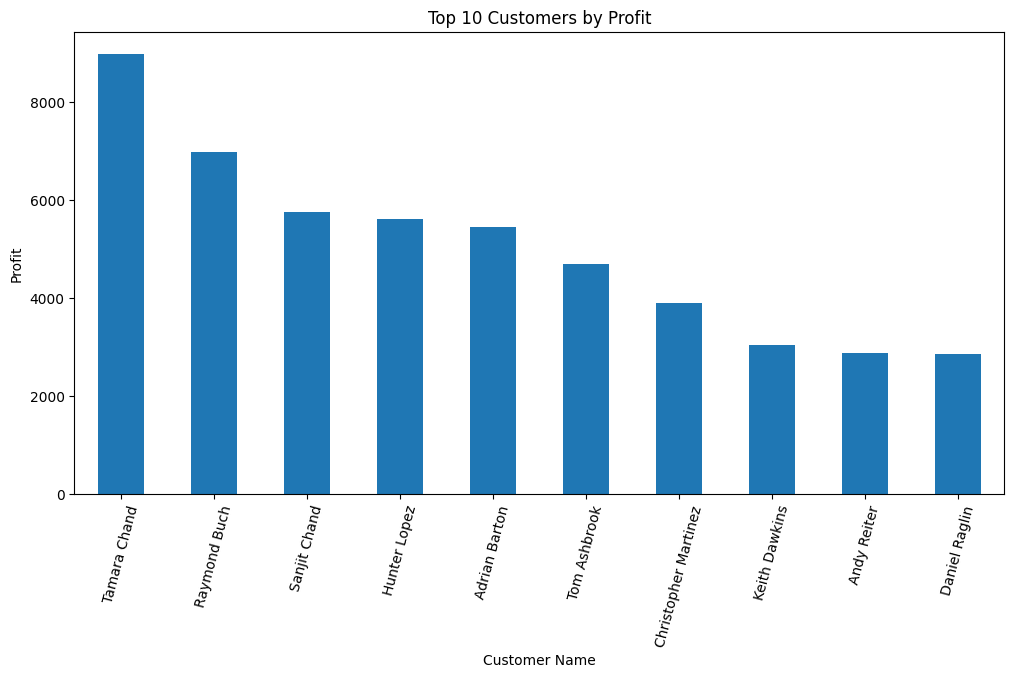

In [123]:
# Top 10 Customers by Profit

customer_profit = df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False).head(10)
print(customer_profit)

# Bar Chart
customer_profit.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Customers by Profit")
plt.xlabel("Customer Name")
plt.ylabel("Profit")

plt.xticks(rotation=75)

plt.savefig("visualizations/customer_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Customer Name
Emily Phan             17
Sally Hughsby          13
Noel Staavos           13
Patrick Gardner        13
Zuschuss Carroll       13
Joel Eaton             13
Erin Ashbrook          13
Chloris Kastensmidt    13
Suzanne McNair         12
Rick Bensley           12
Name: Order ID, dtype: int64


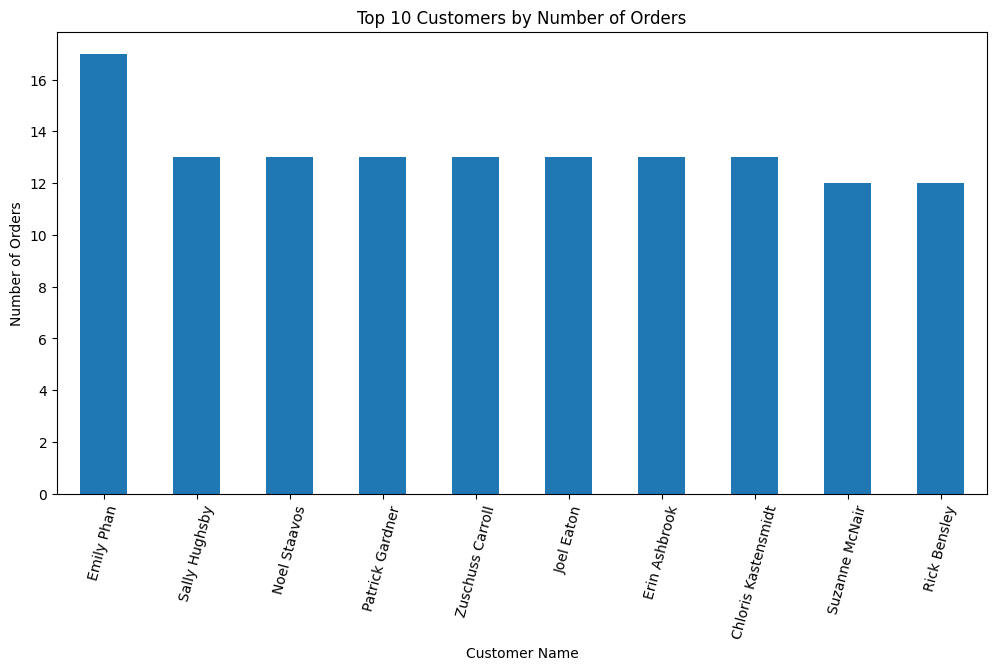

In [124]:
# Top 10 Customers by Number of Orders

customer_orders = df.groupby("Customer Name")["Order ID"].nunique().sort_values(ascending=False).head(10)
print(customer_orders)

# Bar Chart

customer_orders.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Customer Name")
plt.ylabel("Number of Orders")

plt.xticks(rotation=75)

plt.savefig("visualizations/customer_orders.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

### Top 10 Customers by Sales
- **Sean Miller** recorded the highest sales (**25,043.05**), making him the company's highest revenue-generating customer.
- **Tamara Chand** and **Raymond Buch** ranked second and third, contributing significantly to total sales.
- The top 10 customers generated substantial revenue, indicating that a small group of customers contributes a significant portion of overall sales.

### Top 10 Customers by Profit
- **Tamara Chand** generated the highest profit (**8,981.32**), followed by **Raymond Buch** (**6,976.10**) and **Sanjit Chand** (**5,757.41**).
- Although **Sean Miller** generated the highest sales, he did not generate the highest profit, suggesting that higher sales do not always result in higher profitability.
- Several customers appear in both the top sales and top profit lists, indicating they are valuable customers for the business.

### Top 10 Customers by Number of Orders
- **Emily Phan** placed the highest number of unique orders (**17**).
- Several customers placed **13 orders each**, indicating a group of highly active repeat customers.
- Customers with the highest order frequency are not necessarily the highest contributors to sales or profit, showing that frequent purchases do not always result in higher revenue.

# Segment Analysis

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


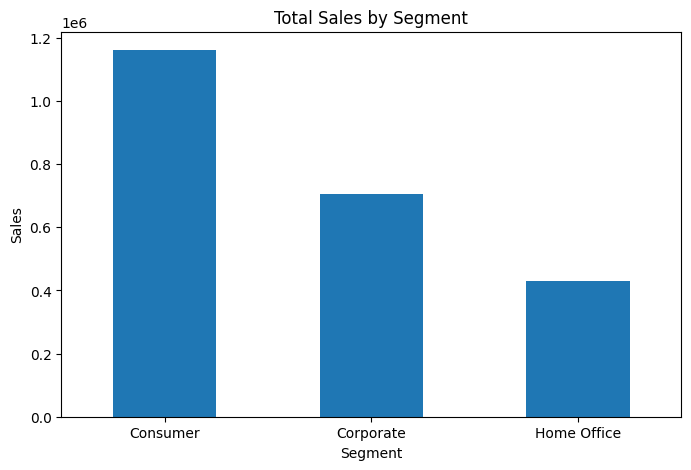

In [125]:
# Total Sales by Segment

segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
print(segment_sales)

# Bar Chart
segment_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.savefig("visualizations/segment_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


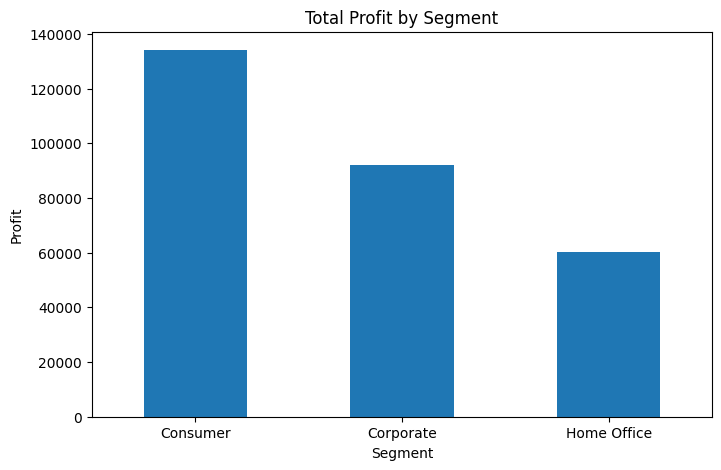

In [126]:
# Total Profit by Segment

segment_profit = df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)
print(segment_profit)

# Bar Chart
segment_profit.plot(kind="bar", figsize=(8,5))

plt.title("Total Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.savefig("visualizations/segment_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Segment
Consumer       19521
Corporate      11608
Home Office     6744
Name: Quantity, dtype: int64


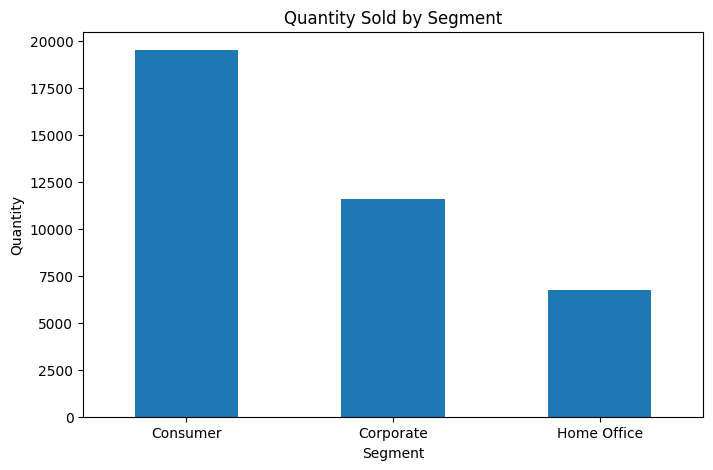

In [127]:
# Total Quantity Sold by Segment

segment_quantity = df.groupby("Segment")["Quantity"].sum().sort_values(ascending=False)
print(segment_quantity)

# Bar Chart
segment_quantity.plot(kind="bar", figsize=(8,5))

plt.title("Quantity Sold by Segment")
plt.xlabel("Segment")
plt.ylabel("Quantity")

plt.xticks(rotation=0)

plt.savefig("visualizations/segment_quantity.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

### Sales by Segment
- The **Consumer** segment generated the highest sales (**1,161,400.81**), making it the largest contributor to the company's total revenue.
- The **Corporate** segment ranked second with **706,146.37** in sales.
- The **Home Office** segment generated the lowest sales (**429,653.15**) among all customer segments.

### Profit by Segment
- The **Consumer** segment earned the highest profit (**134,119.21**), followed by the **Corporate** segment (**91,979.13**).
- The **Home Office** segment generated the lowest profit (**60,298.68**).
- The profit trend closely follows the sales trend across all three customer segments.

### Quantity Sold by Segment
- The **Consumer** segment purchased the highest number of products (**19,521 units**).
- The **Corporate** segment ranked second with **11,608 units**, while the **Home Office** segment purchased **6,744 units**.
- The Consumer segment consistently leads in sales, profit, and quantity sold, indicating that it is the company's strongest-performing customer segment.

# Discount Analysis

Discount
0.00    226.742074
0.10    578.397351
0.15    529.971567
0.20    209.076940
0.30    454.742974
0.32    536.794770
0.40    565.134874
0.45    498.634000
0.50    892.705152
0.60     48.150000
0.70     97.177708
0.80     56.545853
Name: Sales, dtype: float64


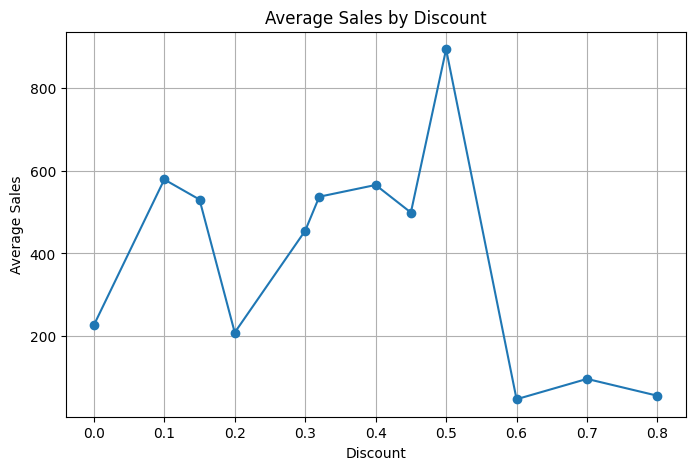

In [128]:
# Average Sales by Discount

discount_sales = df.groupby("Discount")["Sales"].mean().sort_index()
print(discount_sales)

# Line Chart
discount_sales.plot(marker="o", figsize=(8,5))

plt.title("Average Sales by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Sales")

plt.grid(True)

plt.savefig("visualizations/discount_average_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


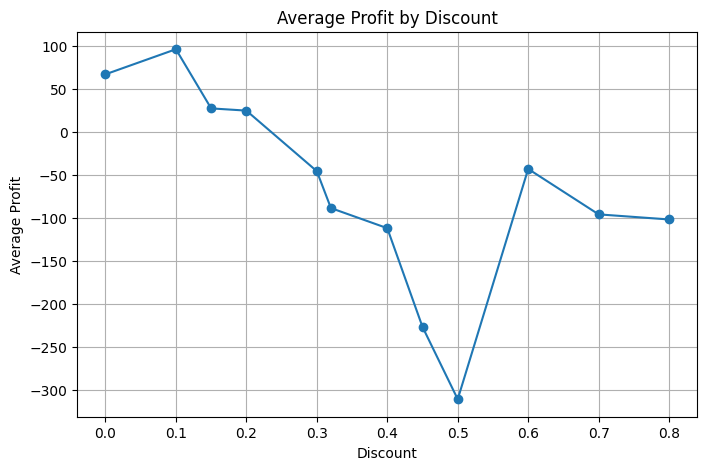

In [129]:
# Average Profit by Discount

discount_profit = df.groupby("Discount")["Profit"].mean().sort_index()
print(discount_profit)

# Line Chart
discount_profit.plot(marker="o", figsize=(8,5))

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.grid(True)

plt.savefig("visualizations/discount_average_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Discount
0.00    1.087908e+06
0.10    5.436935e+04
0.15    2.755852e+04
0.20    7.645944e+05
0.30    1.032267e+05
0.32    1.449346e+04
0.40    1.164178e+05
0.45    5.484974e+03
0.50    5.891854e+04
0.60    6.644700e+03
0.70    4.062028e+04
0.80    1.696376e+04
Name: Sales, dtype: float64


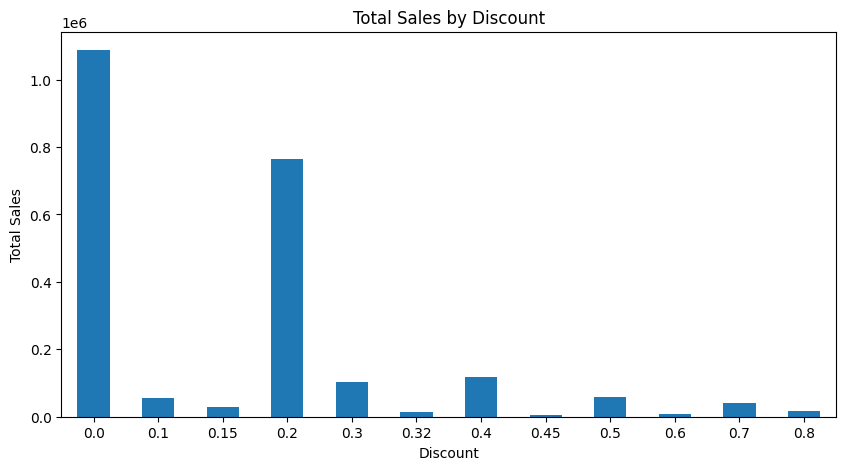

In [130]:
# Total Sales by Discount

discount_total_sales = df.groupby("Discount")["Sales"].sum().sort_index()
print(discount_total_sales)

# Bar Chart
discount_total_sales.plot(kind="bar", figsize=(10,5))

plt.title("Total Sales by Discount")
plt.xlabel("Discount")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.savefig("visualizations/discount_total_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Discount
0.00    320987.6032
0.10      9029.1770
0.15      1418.9915
0.20     90337.3060
0.30    -10369.2774
0.32     -2391.1377
0.40    -23057.0504
0.45     -2493.1111
0.50    -20506.4281
0.60     -5944.6552
0.70    -40075.3569
0.80    -30539.0392
Name: Profit, dtype: float64


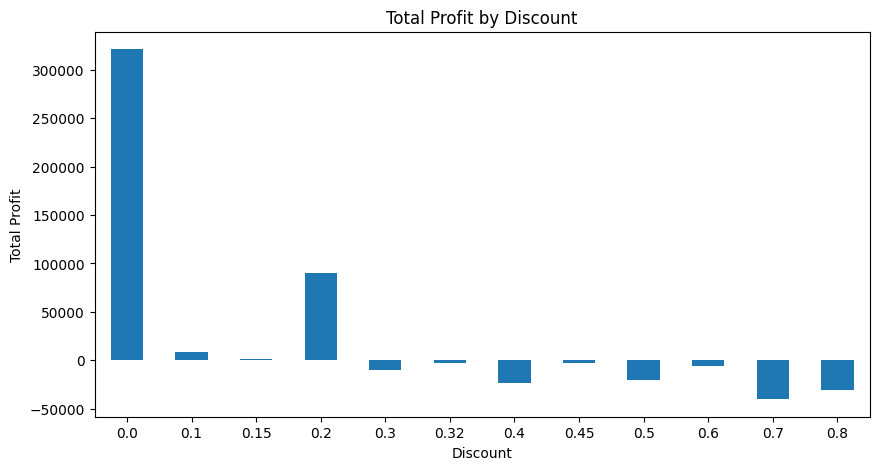

In [131]:
# Total Profit by Discount

discount_total_profit = df.groupby("Discount")["Profit"].sum().sort_index()
print(discount_total_profit)

# Bar Chart
discount_total_profit.plot(kind="bar", figsize=(10,5))

plt.title("Total Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.savefig("visualizations/discount_total_profit.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

### Average Sales by Discount
- Orders with a **50% discount** recorded the highest average sales (**892.71**), followed by **10%** and **40%** discounts.
- Discounts of **60%**, **70%**, and **80%** resulted in the lowest average sales, indicating that very high discounts were generally associated with lower-value orders.
- The average sales do not follow a consistent increasing or decreasing trend as discounts increase.

### Average Profit by Discount
- Orders with **0% discount** generated the highest average profit (**66.90**), while **10% discounts** recorded an even higher average profit (**96.06**).
- Starting from a **30% discount**, the average profit becomes negative and continues to decrease as the discount increases.
- Higher discount levels significantly reduce profitability and often result in losses.

### Total Sales by Discount
- Orders with **no discount (0%)** generated the highest total sales (**1,087,907.54**).
- A **20% discount** also contributed significantly to total sales (**764,594.42**).
- Higher discount levels (60%–80%) contributed relatively little to total sales.

### Total Profit by Discount
- Orders with **no discount** generated the highest total profit (**320,987.60**).
- Orders with a **20% discount** also remained profitable (**90,337.31**).
- Discounts of **30% and above** resulted in overall negative profits, indicating that excessive discounting reduced the company's profitability.

# Time Analysis

In [133]:
# Create Year and Month Columns

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()

# Display first few rows

print(df[["Order Date", "Year", "Month"]].head())

  Order Date  Year     Month
0 2016-11-08  2016  November
1 2016-11-08  2016  November
2 2016-06-12  2016      June
3 2015-10-11  2015   October
4 2015-10-11  2015   October


Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


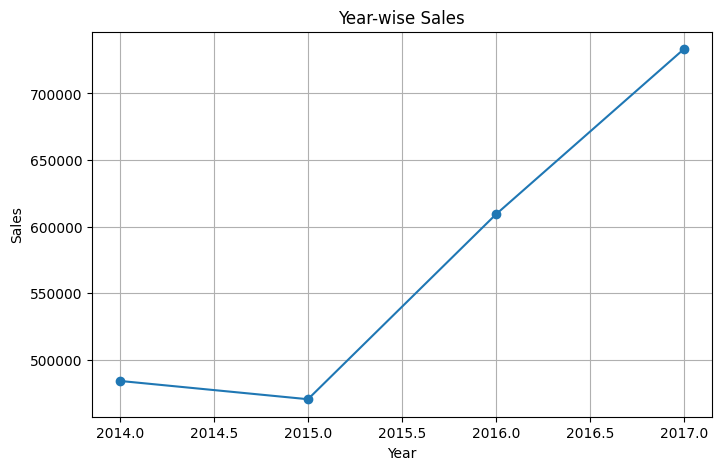

In [136]:
# Total Sales by Year

year_sales = df.groupby("Year")["Sales"].sum()
print(year_sales)

# Line Chart
year_sales.plot(marker="o", figsize=(8,5))

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.savefig("visualizations/year_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64


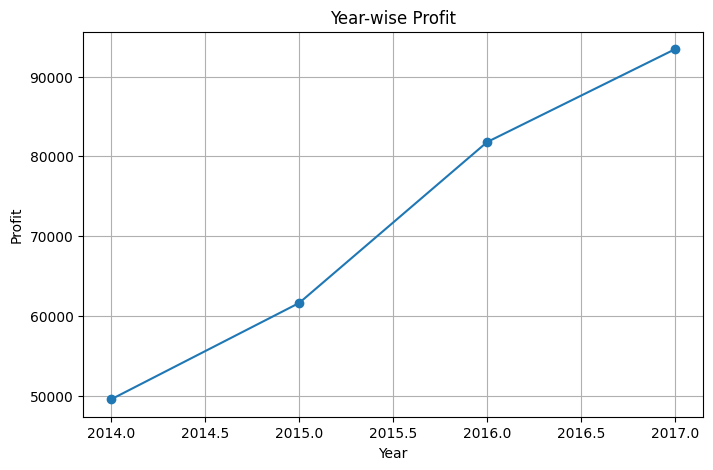

In [137]:
# Total Profit by Year

year_profit = df.groupby("Year")["Profit"].sum()
print(year_profit)

# Line Chart
year_profit.plot(marker="o", figsize=(8,5))

plt.title("Year-wise Profit")
plt.xlabel("Year")
plt.ylabel("Profit")

plt.grid(True)

plt.savefig("visualizations/year_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Month
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64


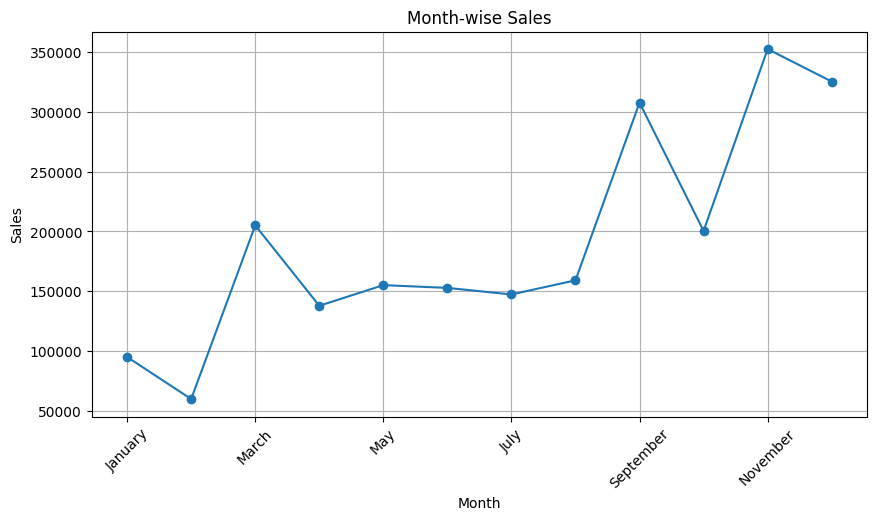

In [138]:
# Arrange Months in Correct Order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Month-wise Sales

month_sales = df.groupby("Month")["Sales"].sum().reindex(month_order)
print(month_sales)

# Line Chart
month_sales.plot(marker="o", figsize=(10,5))

plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.savefig("visualizations/month_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Month
January       9134.4461
February     10294.6107
March        28594.6872
April        11587.4363
May          22411.3078
June         21285.7954
July         13832.6648
August       21776.9384
September    36857.4753
October      31784.0413
November     35468.4265
December     43369.1919
Name: Profit, dtype: float64


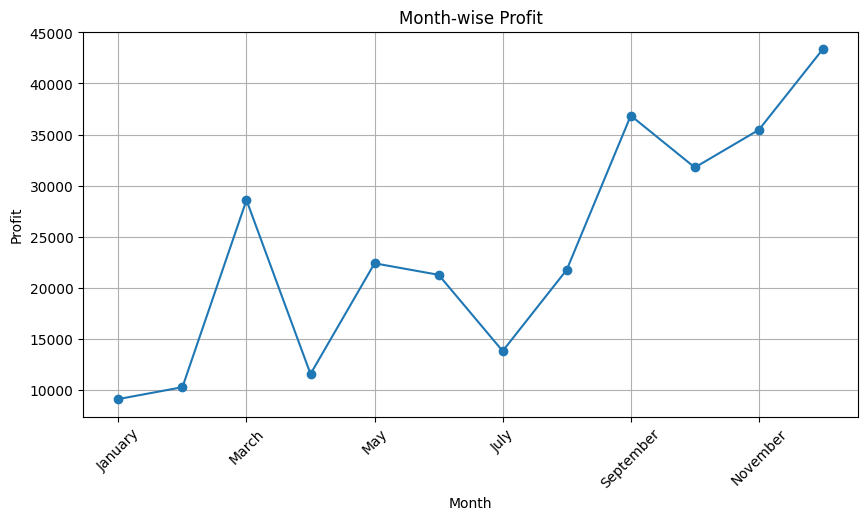

In [139]:
# Total Profit by Month

month_profit = df.groupby("Month")["Profit"].sum().reindex(month_order)
print(month_profit)

# Line Chart
month_profit.plot(marker="o", figsize=(10,5))

plt.title("Month-wise Profit")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.grid(True)

plt.savefig("visualizations/month_profit.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

### Year-wise Sales
- Total sales increased steadily from **2014** to **2017**.
- **2017** recorded the highest sales (**733,215.26**), while **2015** had the lowest sales (**470,532.51**).
- The consistent growth in sales indicates an improvement in the company's business performance over the years.

### Year-wise Profit
- The company's total profit increased every year during the analysis period.
- **2017** generated the highest profit (**93,439.27**), followed by **2016** (**81,795.17**).
- The continuous increase in profit suggests that the company improved its profitability over time.

### Month-wise Sales
- **November** recorded the highest sales (**352,461.07**), followed by **December** (**325,293.50**) and **September** (**307,649.95**).
- **February** generated the lowest sales (**59,751.25**).
- Sales were generally higher during the last few months of the year, indicating increased customer purchases toward year-end.

### Month-wise Profit
- **December** generated the highest profit (**43,369.19**), followed by **September** (**36,857.48**) and **November** (**35,468.43**).
- **January** recorded the lowest profit (**9,134.45**).
- Profit trends generally followed the sales trends, with stronger business performance observed during the final months of the year.

# Correlation Analysis

In [63]:
# Select Numerical Columns

correlation = df[["Sales", "Profit", "Quantity", "Discount"]].corr()

print(correlation)

             Sales    Profit  Quantity  Discount
Sales     1.000000  0.479064  0.200795 -0.028190
Profit    0.479064  1.000000  0.066253 -0.219487
Quantity  0.200795  0.066253  1.000000  0.008623
Discount -0.028190 -0.219487  0.008623  1.000000


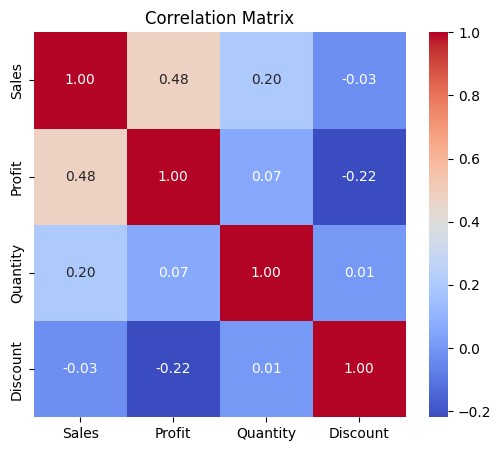

In [140]:
# Heatmap

plt.figure(figsize=(6,5))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")

plt.savefig("visualizations/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation

- There is a **moderate positive correlation (0.48)** between **Sales** and **Profit**, indicating that higher sales generally lead to higher profits.
- **Sales** and **Quantity** have a **weak positive correlation (0.20)**, suggesting that higher sales are influenced not only by the number of products sold but also by product prices.
- **Profit** and **Quantity** show a **very weak positive correlation (0.07)**, indicating that selling more units does not necessarily result in significantly higher profits.
- **Discount** has a **weak negative correlation with Sales (-0.03)**, suggesting that discounts have little impact on increasing overall sales.
- **Discount** has a **negative correlation with Profit (-0.22)**, indicating that higher discounts generally reduce profitability.
- Overall, the correlation analysis suggests that while increasing sales contributes to higher profits, offering excessive discounts can negatively impact the company's profitability.

# Final Insights

1. The company generated a total sales revenue of **2.29 million** and earned a total profit of **286.40 thousand**, indicating overall profitable business performance.

2. **Technology** was the best-performing category in terms of both sales and profit, while **Furniture** generated relatively low profits despite high sales.

3. **Phones** and **Chairs** were the highest revenue-generating sub-categories, whereas **Copiers** generated the highest profit.

4. Some sub-categories, such as **Tables**, **Bookcases**, and **Supplies**, resulted in negative profits, indicating potential pricing or cost-related issues.

5. The **Canon imageCLASS 2200 Advanced Copier** was the highest-performing product in both sales and profit, while stationery products such as **Staples** were sold in the highest quantities.

6. The **West** region consistently recorded the highest sales, profit, and quantity sold, making it the strongest-performing region.

7. **California** was the top-performing state, contributing the highest sales, profit, and quantity sold among all states.

8. The **Consumer** segment generated the highest sales, profit, and quantity sold, making it the company's most valuable customer segment.

9. Customers who generated the highest sales were not always the most profitable, showing that higher revenue does not necessarily result in higher profit.

10. Discounts of **30% and above** generally resulted in negative profits, indicating that excessive discounting reduced overall profitability.

11. Sales and profits increased steadily from **2014 to 2017**, showing consistent business growth over the years.

12. Sales and profits were highest during **September, November, and December**, suggesting stronger business performance toward the end of the year.

13. Correlation analysis showed a moderate positive relationship between **Sales** and **Profit**, while higher discounts showed a negative relationship with profitability.

14. Overall, the analysis highlights strong performance in the Technology category, Consumer segment, West region, and California state, while also identifying areas where profitability can be improved.

# Business Recommendations

1. Focus on expanding the **Technology** category, as it consistently generated the highest sales and profits.

2. Review the pricing and cost structure of the **Furniture** category, especially the **Tables** and **Bookcases** sub-categories, to improve profitability.

3. Reduce or carefully evaluate discounts above **30%**, as they consistently resulted in negative profits.

4. Increase inventory and promotional efforts for high-performing products such as the **Canon imageCLASS 2200 Advanced Copier**, **Phones**, and other profitable technology products.

5. Strengthen marketing strategies in the **West** and **East** regions to maintain their strong sales performance while identifying opportunities to improve business in the **Central** and **South** regions.

6. Analyze the business practices in **California** and apply successful strategies to other states with lower sales and profits.

7. Develop customer loyalty programs for the **Consumer** segment, as it contributes the highest sales, profit, and product demand.

8. Identify and reward high-value customers who consistently generate strong sales and profits to improve customer retention.

9. Plan inventory and marketing campaigns before **September**, **November**, and **December**, as these months recorded the highest sales and profits.

10. Continuously monitor product profitability and discount strategies to ensure long-term business growth while maintaining healthy profit margins.

# Conclusion

This project analyzed the Superstore sales dataset using Python, Pandas, Matplotlib, and Seaborn to understand the company's business performance. The analysis covered key performance indicators, product performance, customer behavior, regional trends, discount impact, time-based trends, and the relationships between important business variables.

The findings revealed that the Technology category, Consumer segment, West region, and California state were the strongest contributors to sales and profit. The analysis also showed that higher discounts negatively affected profitability, while sales and profits consistently increased over the years, indicating positive business growth.

Overall, this project demonstrates how exploratory data analysis can transform raw business data into meaningful insights that support better business decisions. The results can help organizations improve profitability, optimize discount strategies, focus on high-performing products and customers, and make data-driven business decisions.